In [5]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
def estimate_coef(x, y):
    #print(x,y)
    # Número de observaciones/ puntos
    n = len(x)
    # Media de x y y
    m_x = np.mean(x)
    m_y = np.mean(y)
    # Cálculo de desviaciones cruzadas y sobre x
    SS_xy = np.sum(y * x) - n * m_y * m_x
    SS_xx = np.sum(x * x) - n * m_x * m_x
    # Cálculo de coeficientes de regresión
    b_1 = SS_xy / SS_xx
    b_0 = m_y - b_1 * m_x
    return (b_0, b_1)

In [7]:
def plot_regression_line(x, y, b):
  # plotting the actual points as scatter plot
  plt.scatter(x, y, color = "m",
        marker = "o", s = 30)

  # predicted response vector
  y_pred = b[0] + b[1]*x

  # plotting the regression line
  plt.plot(x, y_pred, color = "g")

  # putting labels
  plt.xlabel('Tiempo')
  plt.ylabel('Error predictivo')


In [15]:
def main():
  # observations / data
  x = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8])
  #y = np.array([1, 3, 2, 5, 7, 8, 8, 9, 10, 12])
  #y = np.array([12, 10, 9, 7, 6, 4, 3, 2, 1, 0])
  #y = np.array([1, 2, 3, 4, 5, 4, 3, 2, 1])



  # estimating coefficients
  b = estimate_coef(x, y)
  print("Estimated coefficients:\nb_0 =" + str(b[0]) +" \nb_1 = " + str(b[1]))
  plot_regression_line(x, y, b)

Estimated coefficients:
b_0 =2.7777777777777777 
b_1 = 0.0


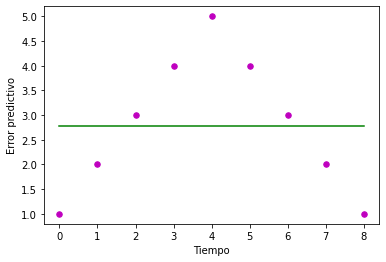

In [16]:
main()

In [6]:
def plot_regression_lines(x, y, b, ax):
    # plotting the actual points as scatter plot
    ax.scatter(x, y, color = "m", marker = "o", s = 30)

    # predicted response vector
    y_pred = b[0] + b[1] * x

    # plotting the regression line
    ax.plot(x, y_pred, color = "g")

    # putting labels
    ax.set_xlabel('x')
    ax.set_ylabel('y')

40


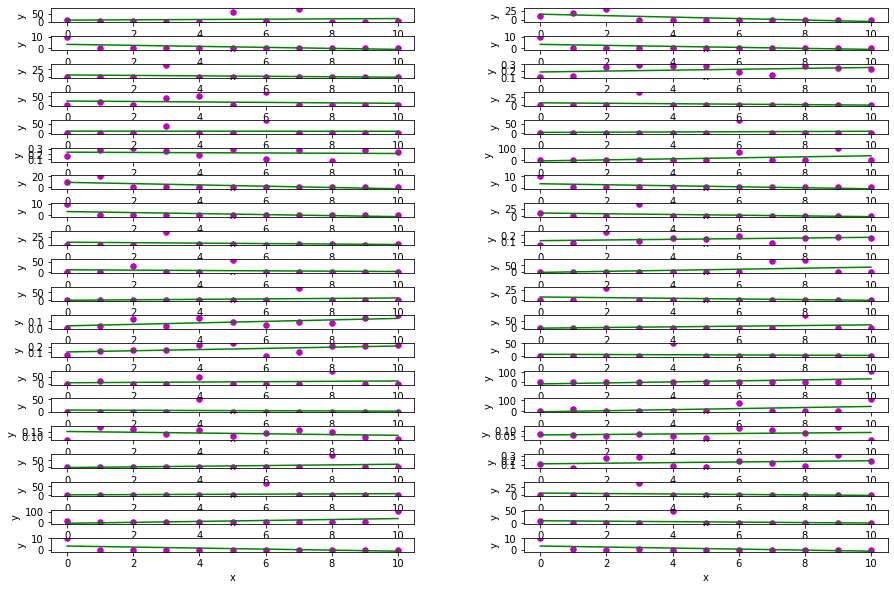

In [7]:
import pandas as pd
import numpy as np

# Load data
#data = pd.read_csv(r'my_project\controllers\my_controller\tasks_train_dataset.csv', sep=',', engine='python') #windows
data = pd.read_csv('my_project/controllers/my_controller/tasks_train_dataset.csv', sep=',', engine='c', header=None) #linux

data = data.values
print(data.shape[0])

time = np.arange(data.shape[1])

num_plots = data.shape[0]  
num_cols = 2  
num_rows = num_plots // num_cols + (num_plots % num_cols > 0)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 10))
axes = axes.flatten()

slopes = []


for i, buffer in enumerate(data):
    lin_reg = estimate_coef(time, buffer)
    slope = lin_reg[1]  # Slope is the second element (b_1)
    #print(buffer)
    #print(lin_reg)
    #print(slope)
    slopes.append(slope)
    plot_regression_lines(time, buffer, lin_reg, axes[i])

#print(slopes)
plt.subplots_adjust(hspace=1, wspace=0.3)
plt.show()